In [ ]:
if 'google.colab' in str(get_ipython()):
    ! git clone -b main https://github.com/edsonportosilva/OptiCommPy
    from os import chdir as cd
    cd('/content/OptiCommPy/')
    ! pip install .

In [4]:
from tqdm.notebook import tqdm
import numpy as np
from numpy.fft import fft, ifft, fftfreq
from  scipy.constants import c
import matplotlib.pyplot as plt

from optic.comm.modulation import modulateGray, grayMapping
from optic.dsp.core import pnorm, upsample, firFilter, pulseShape, signalPower, phaseNoise, decimate, symbolSync
from optic.dsp.equalization import edc
from optic.models.devices import iqm, coherentReceiver, pdmCoherentReceiver, basicLaserModel, mzm, edfa
from optic.models.channels import linearFiberChannel, awgn
from optic.utils import parameters
from optic.plot import pconst, eyediagram, plotPSD
from optic.models.tx import simpleWDMTx
from optic.dsp.carrierRecovery import cpr

c:\GitHub\PIBITI\Marcos_PIBITI\Lib\site-packages\cupyx\jit\_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


## Equalização
---

## Sumário
---
- [Introdução](#introdução)
- [Equalizador Adaptativo](#equalizador-adaptativo)
- [Equalizador Zero-Forçado](#equalizador-zero-forçado)
- [Equalizadores Adaptativos - Algoritmos](#equalizador-adaptativo-algoritmos)
- [Exemplo para mitigar ISI](#exemplo-para-mitigar-ISI)
- [Exemplo para compensação da dispersão cromática](#Exemplo-para-compensação-da-dispersão-cromática)
- [Equalizador MIMO 2 x 2](#equalizador-MIMO-2-x-2)


### Introdução
      
Equalizar um sinal em comunicações significa corrigir ou compensar as distorções causadas pela fibra devido não ser ideal. A equalização visa restaurar o sinal o mais próximo possível da sua forma original antes da detecção minimizando erros, onde um dos principais é a interferência Intersimbólica (ISI), onde a energia de um sinal se espalha causando alargamento do pulso, ruídos ou atenuações.

Sendo isso um dos principais problemas enfrentado, principalmente em sistemas ópticos coerentes, pois envolvem canais dinâmicos e complexos. Um algoritmo de equalização é o conjunto específico de regras e procedimentos que um equalizador usa para compensar as distorções do canal.

O algoritmo define:

- Como o erro entre o sinal equalizado e o sinal desejado (ou uma propriedade conhecida do sinal desejado) é calculado.
- Como esse erro é usado para atualizar os coeficientes do equalizador de forma iterativa.

Exemplos de algoritmos são o CMA (Constant Modulus Algorithm) e o RDE (Radius Directed Equalizer), além do LMS (Least Mean Squares). Cada um tem uma forma diferente de definir o "erro" e a regra de atualização.

### Equalizador Adaptativo

---
<center><img src="https://github.com/Medupl/CoppeliaSim/blob/main/images/Optic/Equalizador%20Adaptativo.png?raw=true"/></center>
<center>Fonte: Diniz, P. S. R., Silva, E. A. B. da, & Netto, S. L.. Processamento Digital de Sinais: Projeto e Análise de Sistemas.</center>

Onde:

**x(k)**: é o sinal. \
**H_{in}(z)**: é o filtro de entrada.\
**H_c(z)**: introduz a distroção.\
**n(k)**: Ruído aditivo.\
**Adaptive \ filter**:Equalizador.\
**y(n)**: A saída do filtro adaptativo.\
$z^{-L}$: Um bloco de atraso.\
**e(k)**: O sinal de erro, calculado como **e(k) = d(k) - y(k)**

Um equalizador adaptativo é um tipo de equalizador que pode automaticamente ajustar seus próprios parâmetros (coeficientes do filtro) em tempo real, diferentemente de um equalizador fixo (cujos parâmetros são pré-definidos para um canal conhecido e invariável no tempo), o equalizador adaptativo "aprende" sobre o canal observando o sinal recebido e ajustando-se continuamente.

Um equalizador adaptativo é uma aplicação específica de um filtro adaptativo. Seu objetivo particular é combater as distorções introduzidas por um canal de comunicação, principalmente a ISI. Portanto, todo equalizador adaptativo é um tipo de filtro adaptativo, mas nem todo filtro adaptativo é um equalizador. A diferença está no propósito específico para o qual o filtro adaptativo está sendo usado.

Além disso existem 2 classes de equalizadores, na cadeia do DSP do receptor, primeiro o sinal é passado por um equalizador de zero forçado onde esse equalizador aplica a resposta em frequência do canal pra tentar desfazer os efeitos da dispersão cromática o problema desse equalizador é que ele não compensa tudo apenas efeitos que não variam com o tempo como a dispersão cromática, por esse motivo precisamos usar um equalizador adaptativo que resolve esse problema retirando alguns efeitos como temperatura, vibração efeitos que variam no tempo e acabam distorcendo o sinal. Equalizador Zero- Forçado:Equalizadores no Domínio da Frequência (FDE - Frequency Domain Equalizers)

CMA (Constant Modulus Algorithm) e RDE (Radius Directed Equalizer) são algoritmos usados em equalizadores adaptativos, especialmente em cenários onde uma sequência de treinamento não está disponível ou não é desejável (equalização cega ou "blind"). Ambos ajustam os coeficientes de um filtro (o equalizador) para modificar o sinal recebido de forma a restaurar certas propriedades que o sinal original possuía antes da distorção pelo canal. O objetivo final é reduzir a ISI e permitir a correta detecção dos símbolos.



### Equalizador Zero-Forçado
---

O Equalizador Zero-Forçado quase sempre vem primeiro no DSP após o front-end óptico. Seu objetivo principal é compensar a grande parte da Dispersão Cromática (CD), que é um efeito linear e relativamente estático e tenta inverter completamente a resposta do canal para forçar a interferência intersimbólica (ISI) a ser zero nos instantes de amostragem ideais. ZF usa os coeficientes estáticos, como a gente usa convolução cíclica em blocos então acaba que não conseguimos eliminar a ISI das bordas do bloco isso também fica pro Equalizador adaptativo resolver.

A Dispersão Cromática (CD) é um fenômeno de distorção que ocorre em fibras ópticas, causando o alargamento dos pulsos de sinal. Isso acontece porque um sinal óptico, é composto por um conjunto de diferentes comprimentos de onda (ou frequências). Dentro da fibra, cada um desses comprimentos de onda viaja a uma velocidade ligeiramente diferente. Como resultado, componentes do mesmo pulso que foram transmitidos juntos chegam ao receptor em momentos distintos, 'espalhando' a energia do pulso no tempo. Este alargamento é uma das principais causas da Interferência Intersimbólica (ISI), onde um símbolo 'borra' os símbolos vizinhos, dificultando a correta identificação dos dados no receptor.

A maior parte da CD é frequentemente compensada por métodos não adaptativos ou lentamente adaptativos no domínio da frequência (FDE). No entanto, equalizadores adaptativos no domínio do tempo (usando CMA, RDE, DD-LMS) podem compensar a CD residual ou variações menores de CD.

No domínio da frequência, a solução da equação de propagação linear com GVD é dada por:

$$H(f) = H_0e^{j\frac{β_2}{2}zω^2},\ β_2 \text{ é o coeficiente de dispersão}$$

Uma dificuldade na implementação da compensação CD no domínio da frequência é que a equalização é realizada em blocos. Quando a equalização é realizada em blocos individuais, não é possível cancelar a interferência intersimbólica (ISI) nas bordas do bloco. Este processo corresponde a uma convolução cíclica do bloco de sinal pelos coeficientes do filtro, o que causa aliasing no tempo.

Uma solução são os métodos de overlap e adição de overlap, que não consomem largura de banda, mas aumentam a complexidade do DSP. Em sistemas de comunicação óptica, os métodos baseados em overlap são geralmente preferidos. O Overlap-Save é uma estratégia de "dividir para conquistar" que processa um sinal em pedaços sobrepostos para usar a eficiência da FFT, e depois "salva" apenas as partes boas de cada resultado para reconstruir o sinal filtrado de forma precisa e contínua.

In [5]:
def freqHCD(Fc, Fs, D, NFFT, L):
    """
    Returns
    -------
    np.array
        Resposta em frequência para dispersão cromática.
    """

    λ = c/Fc # comprimento de onda
    beta2 = -(D * λ**2) / (2 * np.pi * c)
    omega = 2 * np.pi * Fs * fftfreq(NFFT)

    return np.exp(-1j * beta2/2 * omega**2 * L)

def overlap_save(x, h, NFFT):
    """
    Implementa a convolução usando o método FFT de sobreposição e salvamento
    (overlap-and-save).

     Returns
    -------
    np.array
        y_out: sinal de saída filtrado.

    Raises
    ------
    ValueError
        Caso o tamanho da NFFT seja menor que o comprimento do filtro.

    Referências
    -----------
        [1] Processamento Digital de Sinais Paulo S. R. Diniz Eduardo A. B. da Silva Sergio L. Netto
            Projeto e Análise de Sistemas. 2º Ed.
    """
    try:
        nModes = x.shape[1]                                                     # verifica se o sinal contém duas dimensões
    except IndexError:
        nModes = 1
        x = x.reshape((x.size, nModes))                                         # caso o sinal seja de 1D, ele aplica a segunda dimensão

    K = len(h) # filter length
    L = len(x) # signal length

    if NFFT < K:
        raise ValueError("NFFT deve ser maior ou igual ao comprimento do filtro")

    D = (K-1)//2                                                                # Calcula o delay do filtroque será usado para alinhar o sinal
    discard = K - 1                                                             # Define o número de amostras que serão descartadas

    # total number of FFT blocks to be processed
    B = np.ceil((L + discard) / (NFFT - K + 1)).astype(int)

    # pad h with zeros to length NFFT
    h = np.pad(h, (0, NFFT - K), "constant")

    N = np.zeros((NFFT + D,), dtype="complex")                                  # pre-allocate buffer
    y_out = np.zeros((B * (len(N) - discard), nModes), dtype="complex")         # pre-allocate output

    for indMode in range(nModes):
        # overlap-and-save blockwise processing
        lpad = np.pad(x[:, indMode], (discard, NFFT), "constant")

        for blk in range(B):

            # Update next block with overlap K-1
            step = blk * (NFFT - discard)

            # Extracts input blocks of length NFFT.
            N = lpad[step:step+NFFT]

            H = fft(h)
            X = fft(N)

            # circular convolution of each block with the impulse response of the filter.
            y = ifft(X * H)

            # obtains the valid samples by discarding the K-1 overlap.
            y_out[step:step+(NFFT-discard), indMode] = y[discard:]

    # select the output corresponding to the polarizations
    if nModes == 1:
        return y_out[D:D+L].reshape(-1)
    else:
        return y_out[D:D+L]

In [8]:
##################### TRANSMISSOR #####################

# Parametros
M = 16                                                                          # Ordem da modulação
constType = 'qam'                                                               # tipo de modulação
pulseType = 'rrc'                                                               # Pulso a ser utilizado
Rs = 32e9                                                                       # Taxa de símbolos [símbolo/s]
Ts = 1/Rs                                                                       # Período de símbolo em segundos
SpS = 8                                                                         # Amostras por símbolo
Fa = 1/(Ts/SpS)                                                                 # Frequência de amostragem do sinal [amostras/segundo]
Ta = 1/Fa                                                                       # Período de amostragem
Ncoeff = 1024                                                                   # Número de coeficientes do filtro RC
alpha = 0.05                                                                    # Rolloff

# parâmetros do IQM
paramIQM = parameters()
paramIQM.Vπ = 2
paramIQM.Vb = -paramIQM.Vπ

# Laser power
Pi = 100e-3  # potência óptica do laser na entrada do IQM

# Parâmetros da fibra
paramFiber = parameters()
paramFiber.L = 100                                                              # comprimento do enlace [km]
paramFiber.alpha = 0                                                            # coeficiente de perdas [dB/Km]
paramFiber.D = 17                                                               # parâmetro de dispersão [ps/nm/km]
paramFiber.Fs = Fa                                                              # Frequência de amostragem do sinal [amostras/segundo]
paramFiber.Fc = 193.1e12                                                        # Frequencia central Hz

# Matched filtering
paramPulse              = parameters()
paramPulse.pulseType    = pulseType
paramPulse.SpS          = SpS
paramPulse.nFilterTaps  = Ncoeff
paramPulse.pulseRollOff = alpha

# gera uma sequência de bits pseudo-aleatórios que chegam ao transmissor
bitsTx = np.random.randint(2, size = int(1e5*np.log2(M)))
symbTx = modulateGray(bitsTx, M, constType)
symbTx = pnorm(symbTx)
symbTx = symbTx.reshape(-1,2)                                                   # Muda a matriz para 2D, e o -1 é para calcular automaticamente.
symbolsUp = upsample(symbTx, SpS)


if pulseType == "nrz" or pulseType == "rect":
    pulse = pulseShape(paramPulse)
elif pulseType == "rrc":
    pulse = pulseShape(paramPulse)
pulse = pulse/max(abs(pulse))

# formatação de pulso
sigTx = firFilter(pulse, symbolsUp)

##################### optical modulation #####################
Ai = np.sqrt(Pi)
sigTxo = iqm(Ai, 0.1*paramIQM.Vπ*sigTx, paramIQM)
print('Potência média do sinal óptico modulado [dBm]: %.3f dBm'%(10*np.log10(signalPower(sigTxo)/1e-3)))

Potência média do sinal óptico modulado [dBm]: 3.709 dBm


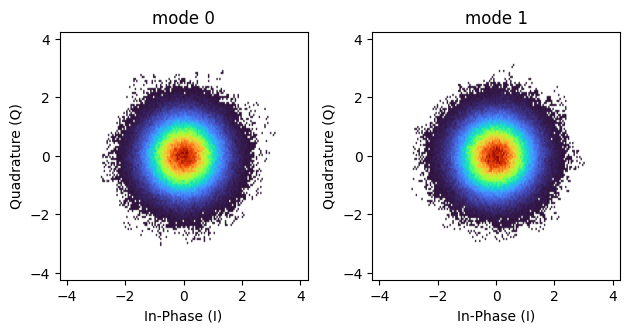

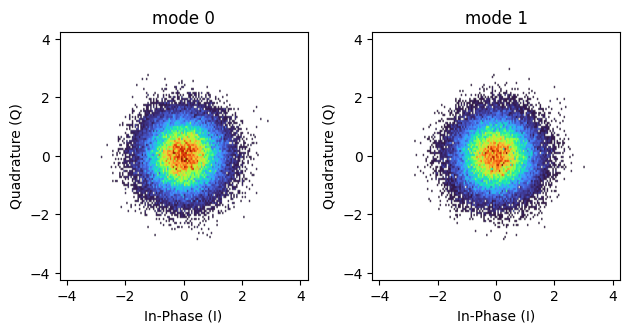

In [10]:
##################### Front-end do receptor coerente #####################
##################### Canal Óptico Linear #####################

# canal óptico linear - adiciona dispersão e perdas
sigRxo = linearFiberChannel(sigTxo, paramFiber)

# parâmetros do receptor
Δf_lo = 0*150e6                                                                 # desvio de frequência do oscilador local
t = np.arange(0, len(sigRxo))*Ta # oscilador local

##################### Canal receptor coerente #####################
# generate CW laser LO field
paramLO = parameters()
paramLO.P = 10              # power in dBm
paramLO.lw = 0*100e3        # laser linewidth
paramLO.RIN_var = 0
paramLO.Ns = len(sigRxo)
paramLO.Fs = Fa

sigLO = basicLaserModel(paramLO)
sigLO = sigLO*np.exp(1j*2*np.pi*Δf_lo*t)                                        # add frequency offset

# photodiodes parameters
paramPD = parameters()
paramPD.B = Rs
paramPD.Fs = Fa
paramPD.ideal = True

# sinal na saída do front-end do receptor coerente
sigRx = pdmCoherentReceiver(sigRxo, sigLO, 0, paramPD)
pconst(sigRx, R=3)

##################### Filtro Casado #####################
# filtro casado
sigRx = firFilter(pulse, sigRx)
pconst(sigRx[0::SpS,:], R=3)

# downsampling to 2 samples/symbol
paramDec = parameters()
paramDec.SpSin      = SpS
paramDec.SpSout     = 2
sigRx = decimate(sigRx, paramDec)

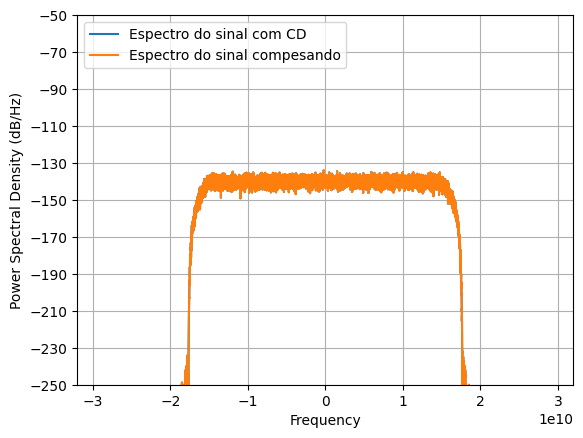

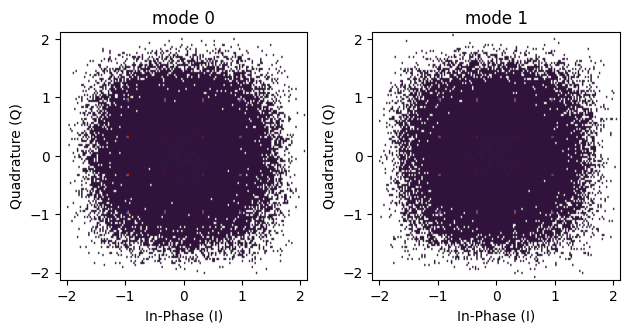

In [12]:
# define o tamanho da FFT
NFFT = 2**11

# obtem a resposta em frequência da dispersão cromática.
HCD = freqHCD(paramFiber.Fc, 2*Rs, paramFiber.D*1e-6, NFFT//2, L=paramFiber.L*1e3)
sigRxEDCout = overlap_save(sigRx, np.fft.fftshift(np.fft.ifft(HCD)), NFFT)

plt.figure()
plt.ylim(-250,-50)
plt.psd(sigRx[:, 0], Fs=2*Rs, NFFT = 16*1024, sides="twosided", label = "Espectro do sinal com CD")
plt.psd(sigRxEDCout[:, 0], Fs=2*Rs, NFFT = 16*1024, sides="twosided", label = "Espectro do sinal compesando")
plt.legend(loc="upper left")
plt.xlim(-Rs,Rs);

# downsampling
paramDec = parameters()
paramDec.SpSin      = SpS
paramDec.SpSout     = 1
sigRx = decimate(sigRx, paramDec)

discard = 5000
ind = np.arange(discard, sigRxEDCout.size-discard)

sigRxEDCout = pnorm(sigRxEDCout)
pconst(sigRxEDCout, R=1.5);

#### Conclusão

> Este código simula um cenário realista de transmissão óptica, onde o sinal sofre uma distorção ao longo da fibra devido à dispersão cromática (CD) — um fenômeno físico no qual diferentes componentes espectrais do sinal óptico viajam a velocidades ligeiramente diferentes, resultando em alargamento temporal do pulso e sobreposição entre símbolos, o que pode causar erros na recepção.

Para corrigir esse efeito indesejado, o código aplica uma técnica de compensação baseada no modelo da frequência determinística da dispersão, utilizando uma convolução eficiente via o método overlap-save. Essa técnica permite aplicar um filtro inverso à resposta da dispersão, "revertendo" o alargamento causado na propagação.

**Resultados observados:**

 - O espectro do sinal após a compensação volta a ser mais plano e limitado na banda útil, o que indica boa recuperação do formato original.
 - A constelação do sinal mostra um padrão mais definido e regular, refletindo melhor separação entre símbolos — apesar de ainda haver alguns ruídos, comuns em simulações com dispersão.


 #### Filtro casado e função decimate

 O que ele faz é aproveitar melhor a banda já disponível da fibra. Ele maximiza a SNR na saída do receptor, alinhando o sinal recebido com o formato ideal do pulso transmitido (ex: NRZ, RRC), compensa parte da distorção causada pelo canal ou pela dispersão, melhora a definição do pulso antes da amostragem, reduzindo o ISI (interferência entre símbolos).

 Antes do downsampling, o algoritmo está operando com SpS = 128, ou seja, 128 amostras por símbolo — muito acima do necessário, isso dá resolução extra no tempo, permitindo trabalhar com forma de pulso, dispersão e equalização de forma mais precisa.

 A função decimate() Reduz a taxa de amostragem, mantendo apenas as amostras mais significativas (ex: 2 por símbolo), após isso, o espectro parece achatado, porque agora o sinal tem poucos pontos por símbolo e a filtragem já removeu a parte espectral inútil.



### Equalizadores Adaptativos

---

Após o primeiro estágio, um equalizador adaptativo (como os que você está estudando, usando algoritmos como CMA, RDE, ou LMS/DD-LMS, muitas vezes em uma estrutura MIMO) entra em ação. Para ajustar Imperfeições ou CD não completamente compensada pelo primeiro equalizador.

CMA / RDE: Frequentemente usados para convergência cega inicial. Eles não precisam de uma sequência de treinamento e são bons para "abrir o olho" do diagrama de constelação, especialmente na presença de PMD e rotações de fase. O CMA é mais simples, o RDE pode ser melhor para QAM de alta ordem.

DD-LMS (Decision-Directed LMS): Geralmente é ativado após o CMA/RDE terem alcançado uma convergência razoável e o erro de bit estimado é baixo o suficiente para que as decisões sobre os símbolos sejam confiáveis. O DD-LMS é bom para rastrear variações mais lentas e refinar a equalização, geralmente levando a um menor erro residual do que os algoritmos cegos, se as decisões forem corretas.

Para muitas aplicações práticas, a família LMS (incluindo DD-LMS) e os algoritmos cegos como CMA e RDE oferecem um bom equilíbrio entre desempenho e complexidade, especialmente com aceleração por GPU como no seu projeto. Melhor solução para PMD: Equalizadores adaptativos MIMO FIR no domínio do tempo, utilizando algoritmos como CMA ou RDE (ou DD-LMS após convergência inicial). A aceleração por GPU é crucial aqui devido à complexidade.

O PMD é causado devido imperfeições na fibra, a polarização é a orientação do campo eletrico, um sinal ao viajar por uma fibra real onde possui imperfeições, é decomposto em dois modos de componentes de polarização ao longo do eixo, essas componentes viajam ligeiramente a velocidades diferentes causando um atraso diferencial, onde surge alargamento e distorsão do sinal.  A PMD é variante no tempo e acopla polarizações, exigindo equalizadores MIMO (Multiple-Input Multiple-Output) adaptativos. CMA, RDE e DD-LMS são amplamente utilizados como os algoritmos de adaptação para os coeficientes desses filtros MIMO FIR para compensar a PMD.
- Como a PMD mistura os sinais nas duas polarizações ortogonais da luz, o receptor coerente detecta dois sinais (polarização X e polarização Y). Um equalizador MIMO processa esses dois sinais de entrada para produzir dois sinais de saída equalizados. A estrutura clássica é um "butterfly" FIR filter de 2 entradas e 2 saídas (ou seja, 4 filtros FIR no total) cujos coeficientes são adaptados. Algoritmos como CMA e RDE são estendidos para a estrutura MIMO (às vezes chamados de MIMO-CMA). O LMS também pode ser usado se uma sequência de treinamento ou decisões estiverem disponíveis. Computacionalmente intensivos devido à estrutura MIMO e à necessidade de adaptação rápida. Aqui, a aceleração por GPU do seu projeto se torna extremamente valiosa.

Dispersão Modal de Polarização (PMD) é um fenômeno que ocorre em fibras ópticas e outros componentes ópticos que limita a taxa de bits e o alcance dos sistemas de comunicação óptica. Para entender:

1. Luz e Polarização: A luz é uma onda eletromagnética. A polarização descreve a orientação do campo elétrico da onda. Em uma fibra óptica ideal, qualquer estado de polarização da luz se propagaria inalterado.

2. Birrefringência da Fibra: Fibras ópticas reais não são perfeitamente circulares e homogêneas. Imperfeições de fabricação, tensões mecânicas (curvaturas, pressões) e variações de temperatura fazem com que a fibra exiba birrefringência. Isso significa que o índice de refração da fibra é ligeiramente diferente para duas direções de polarização ortogonais (os chamados "eixos principais de polarização" ou PSPs - Principal States of Polarization).

3. Velocidades Diferentes: Devido a essa birrefringência, um pulso de luz lançado na fibra, mesmo que inicialmente polarizado linearmente, pode ser decomposto em duas componentes ao longo desses eixos principais de polarização. Essas duas componentes viajam a velocidades ligeiramente diferentes dentro da fibra.

4. Atraso Diferencial de Grupo (DGD): A diferença no tempo de chegada entre essas duas componentes de polarização no final da fibra é chamada de Atraso Diferencial de Grupo (DGD). O DGD é o principal parâmetro que quantifica a PMD em um instante.

5. Consequências:
  - Alargamento do Pulso: Como uma parte do pulso chega antes da outra, o pulso resultante na saída da fibra é alargado, levando à ISI.
  - Distorção do Sinal: A PMD não apenas alarga os pulsos, mas também pode distorcer sua forma e rotacionar o estado de polarização do sinal de maneira complexa.

---
Equação geral dos equalizadores gerais:

$$W(k+1) = W(k) - \mu \nabla J(W(k))$$

#### 1. LMS (Least Mean Squares)

O LMS é um algoritmo supervisionado (ou treinado). Ele ajusta os pesos do filtro para minimizar o erro quadrático médio entre a saída do equalizador e uma sequência de símbolos de treinamento conhecida, que é enviada no início da transmissão.

Equação de Atualização:

$$(k+1)=W(k)+μ⋅X(k)⋅e^∗(k)$$

Componentes da Equação:

_W(k)_: Vetor com os coeficientes atuais do filtro.

_μ_: O "passo de apredizagem", um número pequeno que controla a velocidade e estabilidade da convergência.

_X(k)_: Vetor com as amostras de entrada que estão atualmente no filtro.

_$e^*(k)$_: O conjugado complexo do erro instantâneo. É aqui que a "mágica" acontece. O erro é calculado como:

$$e(k)=d(k)−y(k)$$

_d(k)_: O símbolo desejado (da sequência de treinamento conhecida).

_y(k)_: A saída atual do equalizador $(y(k) = W(k)^H X(k))$.

#### 2. CMA (Constant Modulus Algorithm)

O CMA é um algoritmo de equalização cego (não supervisionado), ou seja, não precisa de uma sequência de treinamento. Ele funciona tentando restaurar uma propriedade do sinal: seu módulo constante (amplitude constante). É ideal para formatos de modulação com amplitude constante, como PSK (QPSK, 8-PSK).

Equação de Atualização:

$$W(k+1)=W(k)−μ⋅X(k)⋅y^∗ (k)⋅(∣y(k)∣^2−R)$$

Componentes da Equação:

_W(k), μ, X(k)_: Idênticos ao LMS.

$y^*(k)$: O conjugado complexo da saída do equalizador.

$(|y(k)|^2 - R^2)$: Este é o termo de erro do CMA. Ele mede o desvio da potência instantânea da saída $(|y(k)|²)$ em relação a uma potência de referência constante $(R²)$.

_y(k)_: A saída atual do equalizador.

R: O raio constante da constelação ideal (ex: R=1 para QPSK).

#### 3. RDE (Radius-Directed Equalizer)

O RDE é um algoritmo cego, frequentemente visto como uma evolução do CMA para constelações de múltiplos anéis, como a QAM. O CMA puro tentaria forçar todos os símbolos QAM para um único raio, distorcendo a constelação. O RDE é mais inteligente.

Equação de Atualização:

$$W(k+1)=W(k)−μ⋅X(k)⋅y∗(k)⋅(∣y(k)∣^2 −Rd(k)^2)$$

Componentes da Equação:

A equação é quase idêntica à do CMA, com uma diferença crucial no termo de erro $(|y(k)|^2 - R_d(k)^2)$.

$R_d(k)$: Este é o raio de decisão (decision-directed radius). Em vez de usar um R fixo como no CMA, o algoritmo RDE primeiro faz uma "pré-decisão": ele olha para a amplitude do símbolo de saída $y(k)$ e decide a qual dos anéis de raio ideais da constelação QAM ele provavelmente pertence. Ele então usa esse raio $R_d(k)$ específico para calcular o erro.

Por exemplo, em uma constelação QAM com raios ideais ${r₁, r₂, r₃}$, se $|y(k)|$ estiver mais perto de r₂, então $R_d(k)$ será definido como r₂ para esta iteração.

### Exemplo para mitigar ISI


In [13]:
def lms(u, d, taps, mu):
    """
    Simples implementação do algoritmo LMS para filtragem adaptativa.

    Returns
    -------
    tuple:
        - np.array: sinal de saída.
        - np.array: sinal de erro.
        - np.array: erro quadrático.
        - np.array: coeficintes do filtro após a convergência.

    Referências
    -----------
    [1] Adaptive Filtering: Algorithms and Practical Implementation
    """

    # número de iterações para filtragem adaptativa
    N = len(u) - taps + 1

    # obém o tipo de um filtro real ou complexo
    dtype = u.dtype

    # obtém o atraso da filtragem FIR
    delay = (taps-1) // 2

    y = np.zeros(len(u), dtype=dtype)     # saída do filtro
    e = np.zeros(len(u), dtype=dtype)     # sinal de erro
    w = np.zeros(taps, dtype=dtype)       # coeficientes iniciais do filtro.

    err_square = np.zeros(len(u), dtype=dtype)   # erro quadrático

    # Execulta a filtragem adaptativa
    for n in range(N):

        # janela deslizante correspondente a ordem do filtro
        x = np.flipud(u[n:n+taps])

        # calcula a saída no instante n
        y[n] = np.dot(x, w)

        # calcula o erro
        e[n] = d[n + delay] - y[n]

        # calcula os novos coeficientes do filtro
        w += mu * np.conj(x) * e[n]

        # calcula o erro quadrático
        err_square[n] = e[n]**2

    return y, e, err_square, w

In [14]:
def cma(u, constSymb, taps, mu):
    """
    Implementação do equalizador de módulo constante.

    Returns
    -------
    tuple:
        - np.array: sinal de saída.
        - np.array: sinal de erro.
        - np.array: coeficintes do filtro após a convergência.

    Referências
    -----------
        [1] Adaptive Filtering: Algorithms and Practical Implementation
    """

    # Constante relacionada às características da modulação.
    R = np.mean(np.abs(constSymb)**4) / np.mean(np.abs(constSymb)**2)

    # Número de iterações para filtragem adaptativa
    N = len(u) - taps + 1

    # Obtém o atraso da filtragem FIR
    delay = (taps - 1) // 2

    y = np.zeros(len(u), dtype="complex")  # saída do filtro
    e = np.zeros(len(u), dtype="complex")  # sinal de erro

    # Inicialização dos coeficientes do filtro
    w = np.zeros(taps, dtype="complex")
    w[delay] = 1

    # Executa a filtragem adaptativa
    for n in range(N):

        # janela deslizante correspondente à ordem do filtro
        x = np.flipud(u[n:n + taps])

        # calcula a saída no instante n
        y[n] = np.dot(w, x)

        # calcula o erro
        e[n] = y[n] * (np.abs(y[n])**2 - R)

        # calcula os novos coeficientes do filtro
        w -= 2 * mu * e[n] * np.conj(x)

    return y, e, w

In [ ]:
# parâmetros da simulação
SpS = 4             # Amostras por símbolo
Rs  = 100e6         # Taxa de símbolos
Ts  = 1/Rs          # Período de símbolo em segundos
Fa  = 1/(Ts/SpS)    # Frequência de amostragem do sinal (amostras/segundo)
Ta  = 1/Fa          # Período de amostragem

M = 4  # ordem do formato de modulação
constType = "qam"

# Simulação de transmissão em canal AWGN
SNRdB = 30  # relação sinal-ruído em dB

# parâmetros do canal linear
hch = np.array([0.207, 0.815, 0.207]) # resposta ao impulso do canal
hch_up = upsample(hch, SpS)

# Define constelação
constSymb_ = grayMapping(M, constType)
Es = np.mean(np.abs(constSymb_**2))

constSymb = pnorm(constSymb_)

# gera sequência de bits pseudo-aleatória
bitsTx = np.random.randint(2, size = int(200000*np.log2(M)))

# gera sequência de símbolos da modulação
symbTx = modulateGray(bitsTx, M, constType)
symbTx = pnorm(symbTx) # normaliza energia média dos símbolos

# upsampling
symbolsUp = upsample(symbTx, SpS)

# formatação de pulso NRZ
pulse = pulseShape("rrc", SpS,  N=2048, alpha=0.01)
sigTx = firFilter(pulse, symbolsUp)
sigTx = pnorm(sigTx)

# canal linear
sigCh = firFilter(hch_up, sigTx)
sigCh = pnorm(sigCh)

# ruído gaussiano branco
Nsamples = sigTx.size
σ2 = 1/(10**(SNRdB/10))
σ  = np.sqrt(σ2*SpS)

if constType == "pam":
    ruido  = np.random.normal(0, σ, Nsamples) # real-valued AWGN
elif constType == "qam":
    ruido  = 1/np.sqrt(2)*(np.random.normal(0, σ, Nsamples) + 1j*np.random.normal(0, σ, Nsamples)) # complex-valued AWGN

# filtro casado
sigRx = firFilter(pulse, sigCh+ruido)
sigRx = pnorm(sigRx)

# diagrama de olho após o filtro casado
eyediagram(sigRx, Nsamples, SpS, plotlabel= str(M)+"-"+constType.upper()+" MF output", ptype="fancy")

In [ ]:
############# Equalização adaptativa ##############
flagAlg = "lms"

# downsampling
y = sigRx[0::SpS]
y = pnorm(y)

# parâmetros do equalizador
Ntaps = 12
mu = 0.005

if flagAlg == "lms":
    # equalizador LMS
    symbRx, erro, squaredError, h_eq = lms(y, symbTx, Ntaps, mu)
    symbRx = pnorm(symbRx)

elif flagAlg == "cma":
    # equalizador CMA
    symbRx, erro, h_eq = cma(y, symbTx, Ntaps, mu)
    symbRx = pnorm(symbRx)

# aplicando o filtro obtido pelo equalizador LMS no sinal obtido na saída do filtro casado
sigLMS = firFilter(upsample(h_eq, SpS), firFilter(pulse, sigCh+ruido))

# observando o diagrama de olho como se o filtro obtido pelo equalizador LMS
# já fosse conhecido e aplicado diretamente na saída do filtro casado
eyediagram(pnorm(sigLMS), Nsamples, SpS, plotlabel= str(M)+"-"+constType.upper()+" after the LMS filter", ptype="fancy")

fig, axs = plt.subplots(1, 2, figsize=(17,3))

axs[0].plot(y, ".", label="saída do canal (ruído + ISI)")
axs[0].plot(symbRx,"k.", label="Após o LMS (Remoção de ISI)")
axs[0].plot(symbTx,".",  label="símbolos transmitidos")
axs[0].legend(loc="best")

axs[1].plot(np.abs(erro), label=f'µ = {mu}')
axs[1].grid()
axs[1].set_ylabel(r'|error|')
axs[1].set_xlabel('Iterações')
plt.show();

Neste código, analisamos o comportamento dos equalizadores adaptativos LMS e CMA frente à interferência intersimbólica (ISI), que surge da forma de pulso e da convolução do canal com ruído. Os resultados mostram que ambos os algoritmos são capazes de adaptar seus coeficientes para minimizar os efeitos do ISI, conforme observado nos diagramas de olho e nos gráficos de erro. Este experimento serve como base introdutória para o entendimento do processo de equalização, antes da introdução de distorções mais complexas como dispersão cromática e PMD, que exigem tratamento mais sofisticado.


### Exemplo para compensação da dispersão cromática

In [ ]:
############## Transmissor ##############
# Parametros

M = 16                                                                          # Ordem da modulação
constType = "qam"                                                               # Esquema de modulação
pulseType = "rrc"                                                               # Pulso a ser utilizado
Rs = 30e9                                                                       # Taxa de símbolos [símbolo/s]
Ts = 1/Rs                                                                       # Período de símbolo em segundos
SpS = 32                                                                        # Amostras por símbolo
Fa = 1/(Ts/SpS)                                                                 # Frequência de amostragem do sinal [amostras/segundo]
Ta = 1/Fa                                                                       # Período de amostragem
Ncoeff = 1024                                                                   # Número de coeficientes do filtro RC
alpha = 0.05                                                                    # Rolloff

# parâmetros do IQM
paramIQM = parameters()
paramIQM.Vπ = 2
paramIQM.Vb = -paramIQM.Vπ

# Laser power
Pi = 100e-3                                                                     # potência óptica do laser na entrada do IQM

# Parâmetros da fibra
paramFiber = parameters()
paramFiber.L = 100                                                              # comprimento do enlace [km]
paramFiber.alpha = 0                                                            # coeficiente de perdas [dB/Km]
paramFiber.D = 17                                                               # parâmetro de dispersão [ps/nm/km]
paramFiber.Fs = Fa                                                              # Frequência de amostragem do sinal [amostras/segundo]

### formatação de pulso ###

plotSpec = False

# gera uma sequência de bits pseudo-aleatórios que chegam ao transmissor
bitsTx = np.random.randint(2, size = int(1e5*np.log2(M)))

symbTx = modulateGray(bitsTx, M, constType)
symbTx = pnorm(symbTx)                                                          # symbol power normalization

symbolsUp = upsample(symbTx, SpS)

if pulseType == "nrz" or pulseType == "rect":
    pulse = pulseShape(pulseType, SpS)
elif pulseType == "rrc":
    pulse = pulseShape("rrc", SpS, Ncoeff, alpha, Ts)

pulse = pulse/max(abs(pulse))

# formatação de pulso
sigTx = firFilter(pulse, symbolsUp)

##############     Modulação Optica        ##############

# Laser power
Pi = 100e-3                                                                     # potência óptica do laser na entrada do IQM

# optical modulation
Ai = np.sqrt(Pi)
sigTxo = iqm(Ai, 0.1*paramIQM.Vπ*sigTx, paramIQM)

print("Potência média do sinal óptico modulado [mW]: %.3f mW"%(signal_power(sigTxo)/1e-3))
print("Potência média do sinal óptico modulado [dBm]: %.3f dBm"%(10*np.log10(signal_power(sigTxo)/1e-3)))

# plota psd
if plotSpec:
    plt.figure();
    plt.ylim(-250,-50);
    plt.psd(sigTxo, Fs=Fa, NFFT = 16*1024, sides='twosided', label = 'Espectro do sinal óptico')
    plt.legend(loc='upper left');
    plt.xlim(-4*Rs,4*Rs);

In [ ]:
############## Front-End Óptico ##############

# parâmetros do receptor
B = 30e9                                                                        # banda do receptor em Hz
Plo_dBm  = 10                                                                   # potência do oscilador local
df_lo    = 0                                                                    # desvio de frequência do oscilador local
phi_lo   = 0                                                                    # fase do oscilador local
lw       = 100                                                                  # laser linewidth Hz
paramCR = parameters()
paramCR.Fs = Fa

# canal óptico linear
sigRxo = linearFiberChannel(sigTxo, paramFiber)

Plo = 10**(Plo_dBm/10)*1e-3 # potência do oscilador local na entrada do receptor

# oscilador local
t = np.arange(0, sigRxo.size)*Ta
phi_pn_lo  = phaseNoise(lw, sigRxo.size, Ta)

sigLO = np.sqrt(Plo)*np.exp(1j*(2*np.pi*df_lo*t + phi_lo + phi_pn_lo))

# sinal na saída do front-end do receptor coerente
print('\nConstelação na saída do front-end coerente:')
sigRx = coherentReceiver(sigRxo, sigLO,paramCR)
pconst(sigRx, R=3);

# filtro casado
print('Constelação na saída do filtro casado:')
sigRx = firFilter(pulse, sigRx)
pconst(sigRx[0::SpS], R=3)

### Equalização adaptativa usando LMS ###
flagAlg = 'lms'

# downsampling
y = sigRx[0::SpS]
y = pnorm(y)

# parâmetros do equalizador
Ntaps = 25
mu = 2e-3

if flagAlg == 'lms':
    # equalizador LMS
    symbRx, erro, squaredError, h_eq = lms(y, symbTx, Ntaps, mu)
    symbRx = pnorm(symbRx)

elif flagAlg == 'cma':
    # equalizador CMA
    symbRx, erro, h_eq = cma(y, symbTx, Ntaps, mu)
    symbRx = pnorm(symbRx)

print('Constelação após a equalização:')

# remova o transiente das primeiras iterações do LMS descartando amostras iniciais
discard = 6000
pconst(symbRx[discard:], R=3);